Bibliotecas utilizadas na análise dos dados

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from banco import conectar

#configuração visual dos gráficos
plt.style.use("ggplot")

#mostra todas as colunas dos resultados
pd.set_option("display.max_columns", None)

print("Bibliotecas carregadas com sucesso.")

conexao = conectar()

print("Conexão realizada com sucesso.")

Bibliotecas carregadas com sucesso.
Conexão realizada com sucesso.


1 - Os cinco Órgãos com maior custo total

Nesta análise os valores totais das viagens foram somados e agrupados pelo órgão superior. Na sequencia foram selecionados os cinco órgãos com maiores gastos

In [7]:
# Consulta os cinco órgãos com maior custo total em viagens

sql_orgaos = """
    SELECT
        nome_orgao_superior AS orgao,
        ROUND(SUM(COALESCE(valor_total, 0)), 2) AS custo_total
    FROM public.silver_viagem
    WHERE nome_orgao_superior IS NOT NULL
      AND TRIM(nome_orgao_superior) <> ''
    GROUP BY nome_orgao_superior
    ORDER BY custo_total DESC
    LIMIT 5;
"""

top_5_orgaos = pd.read_sql_query(sql_orgaos, conexao)

top_5_orgaos

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_98460\3842741277.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_5_orgaos = pd.read_sql_query(sql_orgaos, conexao)


,orgao,custo_total
0,Ministério da Justiça e Segurança Pública,4.869331e+08
1,Ministério da Defesa,1.560703e+08
2,Ministério da Educação,1.112913e+08
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07
4,Ministério da Previdência Social,4.041731e+07


Pereceba que ao rodar o código, os números aparecem em anotação científica. Para facilitar a leitura os valores serão apresentados em milhões no gráfico a seguir:

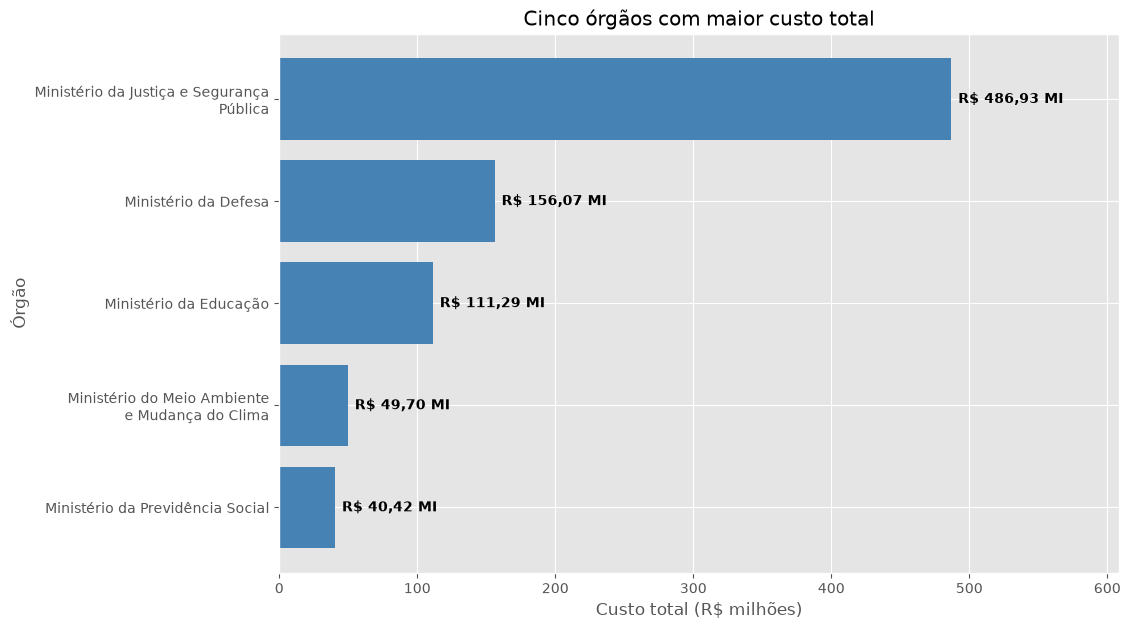

In [ ]:
#quebra textos longos automáticamente em várias linhas com a função fill
from textwrap import fill

#organiza os dados do menor para o maior
dados_grafico = top_5_orgaos.sort_values("custo_total").copy()

#converte os valores para milhões
dados_grafico["custo_milhoes"] = (
    dados_grafico["custo_total"] / 1_000_000
)

#ajusta os nomes longos para não ficarem cortados no gráfico
nomes_orgaos = []

for nome in dados_grafico["orgao"]:
    if "Ministério do Meio Ambiente" in nome:
        nome = nome.replace(
            "Meio Ambiente e ",
            "Meio Ambiente\ne "
        )
    else:
        nome = fill(nome, width=40)

    nomes_orgaos.append(nome)

#define o tamanho do gráfico
fig, ax = plt.subplots(figsize=(14, 7))

#cria as barras horizontais
barras = ax.barh(
    nomes_orgaos,
    dados_grafico["custo_milhoes"],
    color="steelblue"
)

#formata os valores em milhões
rotulos = [
    f"R$ {valor:.2f} MI".replace(".", ",")
    for valor in dados_grafico["custo_milhoes"]
]

#coloca os valores depois das barras
ax.bar_label(
    barras,
    labels=rotulos,
    label_type="edge",
    padding=5,
    color="black",
    fontsize=10,
    fontweight="bold"
)

#cria espaço depois das barras para exibir os valores
maior_valor = dados_grafico["custo_milhoes"].max()
ax.set_xlim(0, maior_valor * 1.25)

#cria o titulo e os nomes dos eixos
ax.set_title("Cinco órgãos com maior custo total")
ax.set_xlabel("Custo total (R$ milhões)")
ax.set_ylabel("Órgão")

#aumenta o espaço mais a esquerda para os nomes dos orgãos
plt.subplots_adjust(left=0.35, right=0.95)

#mostra o gráfico
plt.show()